### Indonesia Military Spending Dataset

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import (SimpleExpSmoothing,Holt, ExponentialSmoothing)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import pmdarima as pm
from pmdarima.model_selection import train_test_split

### Step 1: Load Data

In [ ]:
# Load dataset military spending
data = pd.read_csv('https://raw.githubusercontent.com/royhandaus/Time_Series_Analyst/refs/heads/main/Dataset/military-spending-as-a-share-of-gdp-sipri.csv')

In [ ]:
# Filter data untuk Indonesia saja
indonesia = data[data['Code'] == 'IDN'].copy()

# Ubah kolom 'Year' ke format datetime dan set sebagai index
indonesia['Year'] = pd.to_datetime(indonesia['Year'], format='%Y')
indonesia.set_index('Year', inplace=True)

# Tampilkan beberapa baris pertama
indonesia.head()

,Entity,Code,Military expenditure (% of GDP),World region according to OWID
Year,,,,
1974-01-01,Indonesia,IDN,2.705921,Asia
1975-01-01,Indonesia,IDN,3.492189,Asia
1976-01-01,Indonesia,IDN,3.421868,Asia
1977-01-01,Indonesia,IDN,3.206089,Asia
1978-01-01,Indonesia,IDN,3.163194,Asia


In [ ]:
# Isi missing value di kolom 'constant_usd' dengan interpolasi linear (jika ada)
indonesia['Military expenditure (% of GDP)'].interpolate(method='linear', inplace=True)

/tmp/ipykernel_18447/1290489137.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  indonesia['Military expenditure (% of GDP)'].interpolate(method='linear', inplace=True)


In [ ]:
# Statistik deskriptif
print("Statistik deskriptif pengeluaran Militer Indonesia:")
print(indonesia['Military expenditure (% of GDP)'].describe())

Statistik deskriptif pengeluaran Militer Indonesia:
count    52.000000
mean      1.413305
std       0.888719
min       0.571134
25%       0.748473
50%       0.982416
75%       1.794082
max       3.492189
Name: Military expenditure (% of GDP), dtype: float64


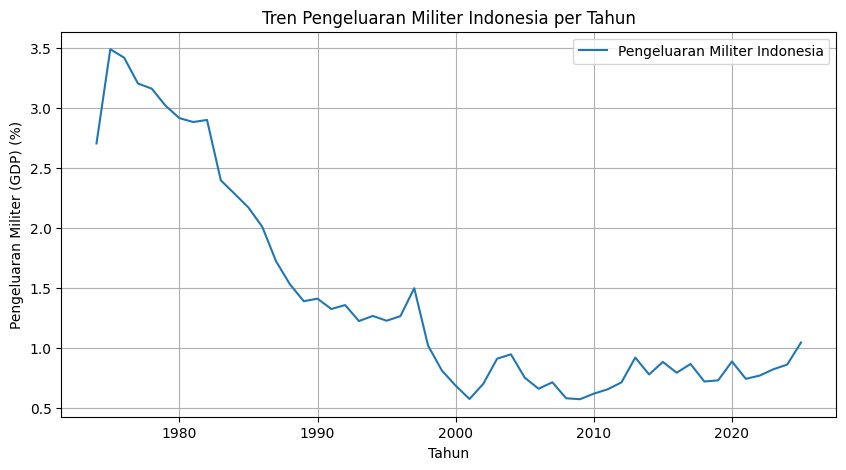

In [ ]:
# Visualisasi tren
plt.figure(figsize=(10,5))
plt.plot(indonesia.index, indonesia['Military expenditure (% of GDP)'], label='Pengeluaran Militer Indonesia')
plt.title('Tren Pengeluaran Militer Indonesia per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Pengeluaran Militer (GDP) (%)')
plt.grid(True)
plt.legend()
plt.show()

### Step 2: Exploratory analysis of data

In [ ]:
# Cek apakah ada missing value di dataset
print("Jumlah missing value per kolom:")
print(indonesia.isna().sum())

Jumlah missing value per kolom:
Entity                             0
Code                               0
Military expenditure (% of GDP)    0
World region according to OWID     0
dtype: int64


### Step 3: Split Data

In [ ]:
# Membagi data menjadi train dan test dengan proporsi 80:20
y = indonesia['Military expenditure (% of GDP)']
train_size = int(len(y)*0.8)
train, test = y[:train_size], y[train_size:]

print(f"Data train: {len(train)} baris, Data test: {len(test)} baris")

Data train: 41 baris, Data test: 11 baris


In [ ]:
y

,Military expenditure (% of GDP)
Year,
1974-01-01,2.705921
1975-01-01,3.492189
1976-01-01,3.421868
1977-01-01,3.206089
1978-01-01,3.163194
1979-01-01,3.020259
1980-01-01,2.917218
1981-01-01,2.884622
1982-01-01,2.901928


In [ ]:
train

,Military expenditure (% of GDP)
Year,
1974-01-01,2.705921
1975-01-01,3.492189
1976-01-01,3.421868
1977-01-01,3.206089
1978-01-01,3.163194
1979-01-01,3.020259
1980-01-01,2.917218
1981-01-01,2.884622
1982-01-01,2.901928


In [ ]:
test

,Military expenditure (% of GDP)
Year,
2015-01-01,0.882267
2016-01-01,0.792220
2017-01-01,0.865191
2018-01-01,0.718928
2019-01-01,0.728564
2020-01-01,0.886278
2021-01-01,0.741526
2022-01-01,0.768013
2023-01-01,0.821108


### Step 4: Create Models based on train data

In [ ]:
# ARIMA model
arima = pm.auto_arima(train, seasonal=False, error_action='ignore')

arima

ARIMA(order=(0, 1, 0), scoring_args={}, suppress_warnings=True)

In [ ]:
# Random Forest Model
X = np.arange(len(y)).reshape(-1, 1)
train_X, test_X = X[:train_size], X[train_size:]
train_y, test_y = y[:train_size], y[train_size:]

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(train_X, train_y)

RandomForestRegressor(random_state=42)

### Step 5: Do Forecasting

In [ ]:
forecast_arima = arima.predict(test.shape[0])
print(f"forecast_arima shape: {forecast_arima.shape}")
forecast_rf = rf_model.predict(test_X)
print(f"forecast_Random Forest shape: {forecast_rf.shape}")

forecast_arima shape: (11,)
forecast_Random Forest shape: (11,)


### Step 6: Compare the forecasting results with test data

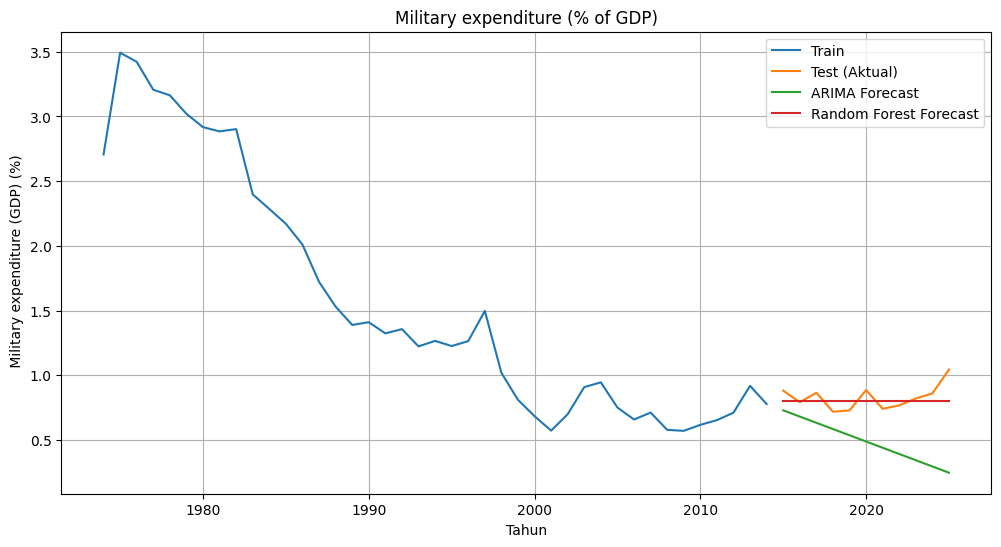

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train , label='Train')
plt.plot(test.index, test , label='Test (Aktual)')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.plot(test.index, forecast_rf, label='Random Forest Forecast')
plt.title('Military expenditure (% of GDP)')
plt.xlabel('Tahun')
plt.ylabel(' Military expenditure (GDP) (%)')
plt.legend()
plt.grid(True)
plt.show()

### Step 7: Measure the model accuracy values (MSE and MAPE)

In [ ]:
# Evaluasi dengan MAPE
mape_arima = mean_absolute_percentage_error(test, forecast_arima)
mape_rf = mean_absolute_percentage_error(test, forecast_rf)

print("MAPE ARIMA:", mape_arima)
print("MAPE Random Forest:", mape_rf)

# Evaluasi dengan MSE
mse_arima = mean_squared_error(test, forecast_arima)
mse_rf = mean_squared_error(test, forecast_rf)

print("MSE ARIMA:", mse_arima)
print("MSE Random Forest:", mse_rf)


MAPE ARIMA: 0.3976626076062404
MAPE Random Forest: 0.08516338439044936
MSE ARIMA: 0.1559550296927929
MSE Random Forest: 0.008755733332691846


<br>

## Indonesia Healthcare Spending Dataset

### Step 1: Load Data

In [ ]:
# Load dataset
data = pd.read_csv('https://raw.githubusercontent.com/royhandaus/Time_Series_Analyst/refs/heads/main/Dataset/public-health-expenditure-share-gdp.csv')

In [ ]:
# Filter data untuk Indonesia saja
indonesia = data[data['Code'] == 'IDN'].copy()

# Ubah kolom 'Year' ke format datetime dan set sebagai index
indonesia['Year'] = pd.to_datetime(indonesia['Year'], format='%Y')
indonesia.set_index('Year', inplace=True)

# Tampilkan beberapa baris pertama
indonesia.head()

,Entity,Code,Public health expenditure as a share of GDP
Year,,,
2000-01-01,Indonesia,IDN,0.585
2001-01-01,Indonesia,IDN,0.782
2002-01-01,Indonesia,IDN,0.673
2003-01-01,Indonesia,IDN,0.813
2004-01-01,Indonesia,IDN,0.748


In [ ]:
# Isi missing value di kolom 'constant_usd' dengan interpolasi linear (jika ada)
indonesia['Public health expenditure as a share of GDP'].interpolate(method='linear', inplace=True)

/tmp/ipykernel_18447/2332359675.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  indonesia['Public health expenditure as a share of GDP'].interpolate(method='linear', inplace=True)


In [ ]:
# Statistik deskriptif dari pengeluaran militer Indonesia
print("Statistik deskriptif pengeluaran Kesehatan Indonesia:")
print(indonesia['Public health expenditure as a share of GDP'].describe())

Statistik deskriptif pengeluaran Kesehatan Indonesia:
count    24.000000
mean      1.075667
std       0.417865
min       0.585000
25%       0.772750
50%       0.933000
75%       1.381750
max       2.263000
Name: Public health expenditure as a share of GDP, dtype: float64


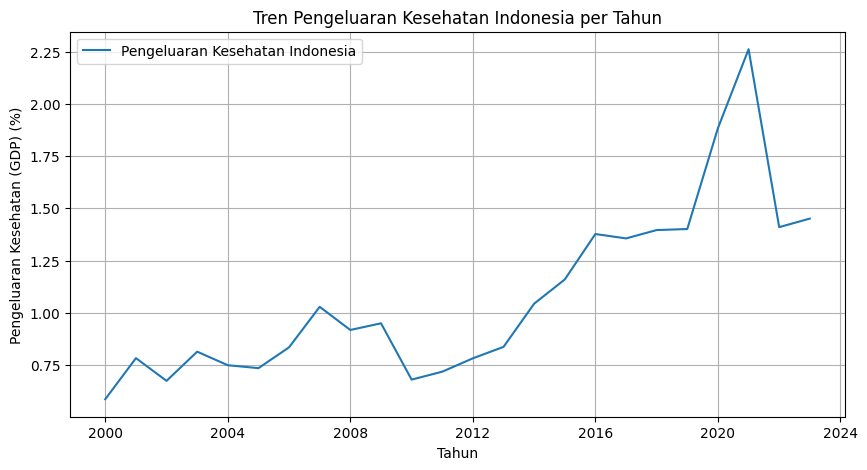

In [ ]:
# Visualisasi tren
plt.figure(figsize=(10,5))
plt.plot(indonesia.index, indonesia['Public health expenditure as a share of GDP'], label='Pengeluaran Kesehatan Indonesia')
plt.title('Tren Pengeluaran Kesehatan Indonesia per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Pengeluaran Kesehatan (GDP) (%)')
plt.grid(True)
plt.legend()
plt.show()

### Step 2: Exploratory analysis of data

In [ ]:
# Cek apakah ada missing value di dataset
print("Jumlah missing value per kolom:")
print(indonesia.isna().sum())

Jumlah missing value per kolom:
Entity                                         0
Code                                           0
Public health expenditure as a share of GDP    0
dtype: int64


### Step 3: Split Data

In [ ]:
# Membagi data menjadi train dan test dengan proporsi 80:20
y = indonesia['Public health expenditure as a share of GDP']
train_size = int(len(y)*0.8)
train, test = y[:train_size], y[train_size:]

print(f"Data train: {len(train)} baris, Data test: {len(test)} baris")

Data train: 19 baris, Data test: 5 baris


In [ ]:
y

,Public health expenditure as a share of GDP
Year,
2000-01-01,0.585
2001-01-01,0.782
2002-01-01,0.673
2003-01-01,0.813
2004-01-01,0.748
2005-01-01,0.734
2006-01-01,0.834
2007-01-01,1.028
2008-01-01,0.917


In [ ]:
train

,Public health expenditure as a share of GDP
Year,
2000-01-01,0.585
2001-01-01,0.782
2002-01-01,0.673
2003-01-01,0.813
2004-01-01,0.748
2005-01-01,0.734
2006-01-01,0.834
2007-01-01,1.028
2008-01-01,0.917


In [ ]:
test

,Public health expenditure as a share of GDP
Year,
2019-01-01,1.401
2020-01-01,1.884
2021-01-01,2.263
2022-01-01,1.410
2023-01-01,1.451


### Step 4: Create Models based on train data

In [ ]:
# ARIMA model
arima = pm.auto_arima(train, seasonal=False, error_action='ignore')

arima

ARIMA(order=(0, 1, 0), scoring_args={}, suppress_warnings=True)

In [ ]:
# Random Forest Model
X = np.arange(len(y)).reshape(-1, 1)
train_X, test_X = X[:train_size], X[train_size:]
train_y, test_y = y[:train_size], y[train_size:]

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(train_X, train_y)

RandomForestRegressor(random_state=42)

### Step 5: Do Forecasting

In [ ]:
forecast_arima = arima.predict(test.shape[0])
print(f"forecast_arima shape: {forecast_arima.shape}")
forecast_rf = rf_model.predict(test_X)
print(f"forecast_Random Forest shape: {forecast_rf.shape}")

forecast_arima shape: (5,)
forecast_Random Forest shape: (5,)


### Step 6: Compare the forecasting results with test data

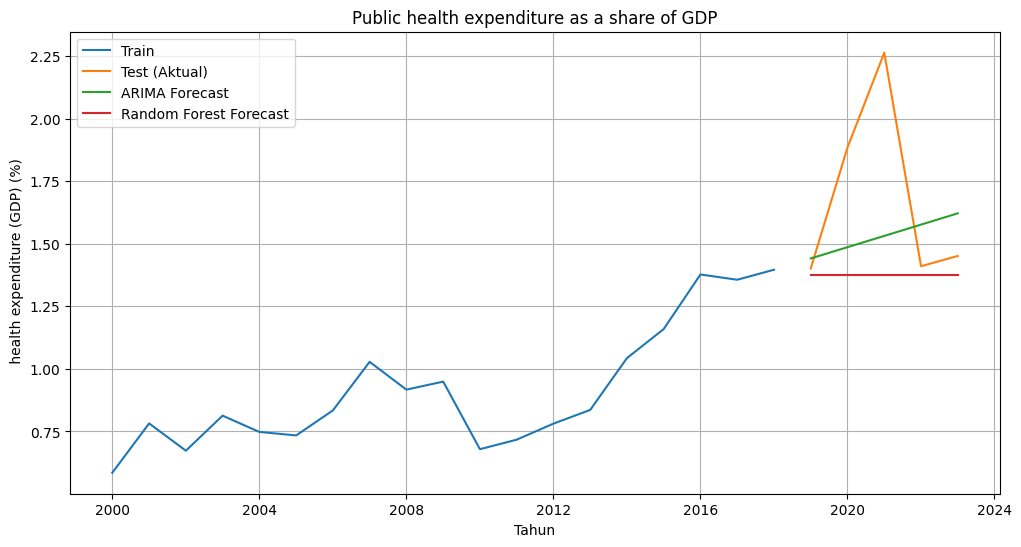

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train , label='Train')
plt.plot(test.index, test , label='Test (Aktual)')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.plot(test.index, forecast_rf, label='Random Forest Forecast')
plt.title('Public health expenditure as a share of GDP')
plt.xlabel('Tahun')
plt.ylabel(' health expenditure (GDP) (%)')
plt.legend()
plt.grid(True)
plt.show()

### Step 7: Measure the model accuracy values (MSE and MAPE)

In [ ]:
# Evaluasi dengan MAPE
mape_arima = mean_absolute_percentage_error(test, forecast_arima)
mape_rf = mean_absolute_percentage_error(test, forecast_rf)

print("MAPE ARIMA:", mape_arima)
print("MAPE Random Forest:", mape_rf)

# Evaluasi dengan MSE
mse_arima = mean_squared_error(test, forecast_arima)
mse_rf = mean_squared_error(test, forecast_rf)

print("MSE ARIMA:", mse_arima)
print("MSE Random Forest:", mse_rf)


MAPE ARIMA: 0.1596827017240668
MAPE Random Forest: 0.1514681413325319
MSE ARIMA: 0.1504250970835774
MSE Random Forest: 0.2108641504000003


<br>

## Indonesia Education Spending Dataset

### Step 1: Load Data

In [ ]:
# Load dataset military spending
data = pd.read_csv('https://raw.githubusercontent.com/royhandaus/Time_Series_Analyst/refs/heads/main/Dataset/government-spending-on-education-as-a-share-of-gdp.csv')

In [ ]:
# Filter data untuk Indonesia saja
indonesia = data[data['Code'] == 'IDN'].copy()

# Ubah kolom 'Year' ke format datetime dan set sebagai index
indonesia['Year'] = pd.to_datetime(indonesia['Year'], format='%Y')
indonesia.set_index('Year', inplace=True)

# Filter data dari tahun 2001 ke atas
indonesia = indonesia[indonesia.index.year >= 2001]

# Buat range tahun lengkap dari 2001 hingga tahun terakhir
all_years = pd.date_range(start='2001', end=indonesia.index.max(), freq='YS')

# Reindex ke tahun lengkap
indonesia = indonesia.reindex(all_years)

# Interpolasi nilai yang hilang (termasuk tahun 2006)
indonesia.interpolate(method='linear', inplace=True)

/tmp/ipykernel_18447/2400486664.py:18: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  indonesia.interpolate(method='linear', inplace=True)


In [ ]:
indonesia.head()

,Entity,Code,Total across all levels of education
2001-01-01,Indonesia,IDN,2.46003
2002-01-01,Indonesia,IDN,2.64569
2003-01-01,Indonesia,IDN,3.21800
2004-01-01,Indonesia,IDN,2.74847
2005-01-01,Indonesia,IDN,2.87282


In [ ]:
# Isi missing value di kolom 'constant_usd' dengan interpolasi linear (jika ada)
indonesia['Total across all levels of education'].interpolate(method='linear', inplace=True)

/tmp/ipykernel_18447/379768205.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  indonesia['Total across all levels of education'].interpolate(method='linear', inplace=True)


In [ ]:
# Statistik deskriptif dari pengeluaran militer Indonesia
print("Statistik deskriptif Education Expenditure:")
print(indonesia['Total across all levels of education'].describe())

Statistik deskriptif Education Expenditure:
count    23.000000
mean      2.366272
std       1.020054
min       0.863943
25%       1.131739
50%       2.812280
75%       3.203720
max       3.583600
Name: Total across all levels of education, dtype: float64


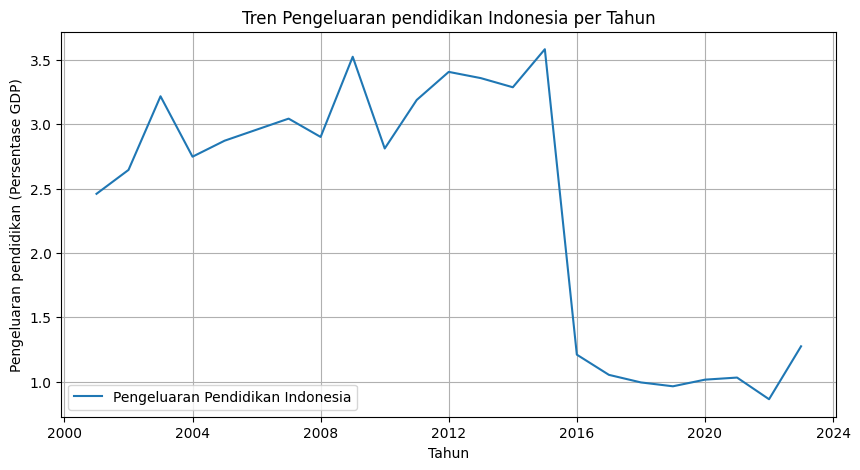

In [ ]:
# Visualisasi tren pengeluaran militer Indonesia selama tahun-tahun data tersedia
plt.figure(figsize=(10,5))
plt.plot(indonesia.index, indonesia['Total across all levels of education'], label='Pengeluaran Pendidikan Indonesia')
plt.title('Tren Pengeluaran pendidikan Indonesia per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Pengeluaran pendidikan (Persentase GDP)')
plt.grid(True)
plt.legend()
plt.show()

### Step 2: Exploratory analysis of data

In [ ]:
# Cek apakah ada missing value di dataset
print("Jumlah missing value per kolom:")
print(indonesia.isna().sum())

Jumlah missing value per kolom:
Entity                                  1
Code                                    1
Total across all levels of education    0
dtype: int64


### Step 3 : Split Data

In [ ]:
# Membagi data menjadi train dan test dengan proporsi 80:20
y = indonesia['Total across all levels of education']
train_size = int(len(y)*0.8)
train, test = y[:train_size], y[train_size:]

print(f"Data train: {len(train)} baris, Data test: {len(test)} baris")

Data train: 18 baris, Data test: 5 baris


In [ ]:
y

,Total across all levels of education
2001-01-01,2.460030
2002-01-01,2.645690
2003-01-01,3.218000
2004-01-01,2.748470
2005-01-01,2.872820
2006-01-01,2.958535
2007-01-01,3.044250
2008-01-01,2.901900
2009-01-01,3.525130
2010-01-01,2.812280


In [ ]:
train

,Total across all levels of education
2001-01-01,2.460030
2002-01-01,2.645690
2003-01-01,3.218000
2004-01-01,2.748470
2005-01-01,2.872820
2006-01-01,2.958535
2007-01-01,3.044250
2008-01-01,2.901900
2009-01-01,3.525130
2010-01-01,2.812280


In [ ]:
test

,Total across all levels of education
2019-01-01,0.964399
2020-01-01,1.015932
2021-01-01,1.032218
2022-01-01,0.863943
2023-01-01,1.275171


### Step 4: Create Models based on train data

In [ ]:
# ARIMA model
arima = pm.auto_arima(train, seasonal=False, error_action='ignore')

arima

ARIMA(order=(1, 0, 0), scoring_args={}, suppress_warnings=True)

In [ ]:
# Random Forest Model
X = np.arange(len(y)).reshape(-1, 1)
train_X, test_X = X[:train_size], X[train_size:]
train_y, test_y = y[:train_size], y[train_size:]

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(train_X, train_y)

RandomForestRegressor(random_state=42)

### Step 5: Do Forecasting

In [ ]:
forecast_arima = arima.predict(test.shape[0])
print(f"forecast_arima shape: {forecast_arima.shape}")
forecast_rf = rf_model.predict(test_X)
print(f"forecast_Random Forest shape: {forecast_rf.shape}")

forecast_arima shape: (5,)
forecast_Random Forest shape: (5,)


### Step 6: Compare the forecasting results with test data

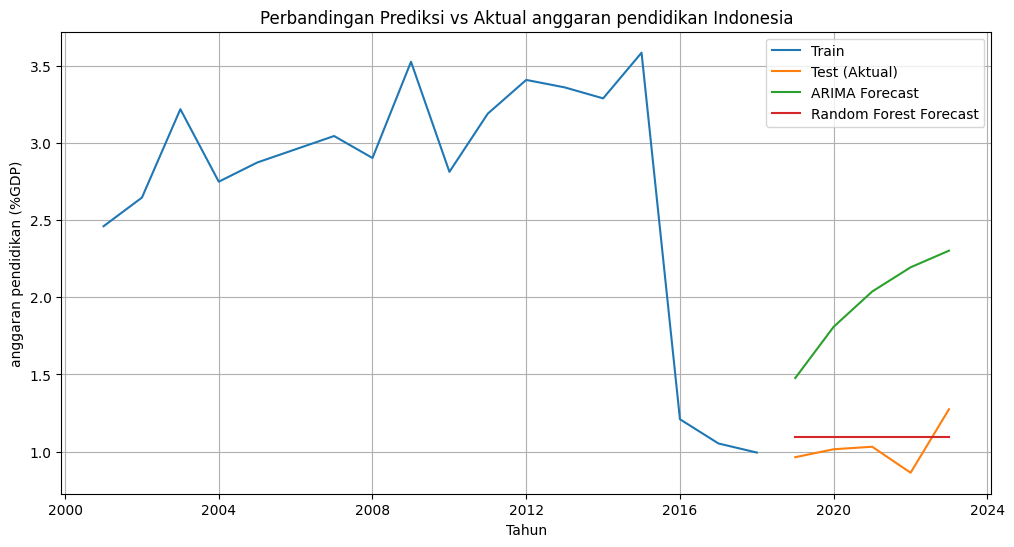

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test (Aktual)')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.plot(test.index, forecast_rf, label='Random Forest Forecast')
plt.title('Perbandingan Prediksi vs Aktual anggaran pendidikan Indonesia')
plt.xlabel('Tahun')
plt.ylabel('anggaran pendidikan (%GDP)')
plt.legend()
plt.grid(True)
plt.show()


### Step 7: Measure the model accuracy values (MSE and MAPE)

In [ ]:
# Evaluasi dengan MAPE
mape_arima = mean_absolute_percentage_error(test, forecast_arima)
mape_rf = mean_absolute_percentage_error(test, forecast_rf)

print("MAPE ARIMA:", mape_arima)
print("MAPE Random Forest:", mape_rf)

# Evaluasi dengan MSE
mse_arima = mean_squared_error(test, forecast_arima)
mse_rf = mean_squared_error(test, forecast_rf)

print("MSE ARIMA:", mse_arima)
print("MSE Random Forest:", mse_rf)


MAPE ARIMA: 0.926183468956687
MAPE Random Forest: 0.13745564683322267
MSE ARIMA: 0.9451201216345467
MSE Random Forest: 0.02279338184638279
